This assignment deals with principal component analysis (PCA) and linear discriminant analysis (LDA).



# PCA
First, you will experiment with PCA. This will also serve as your introduction to the scikit-learn library. For more information about the PCA module in the scikit-learn library, go to http://scikit-learn.org/stable/modules/decomposition.html#decompositions.

One of the basic assumptions of machine learning is that the high dimensional data we observe actually occupies a much lower dimensional manifold. A good description of the low-dimensional manifold is highly desirable. In fact, this is exactly what we try to accomplish when we manufacture *features* for our system. In general, the manifolds will be nonlinear; PCA is an efficient technique for identifying linear, low-dimensional manifolds. 

### Steps of Principal Component Analysis (PCA):
1. **Standardization**: Mean-center the data (subtract the mean of each feature from the dataset).
2. **Covariance Matrix**: Compute the covariance matrix of the mean-centered data to expose feature relationships.
3. **Eigendecomposition**: Calculate the eigenvalues and eigenvectors of the covariance matrix.
4. **Principal Components Selection**: Sort eigenvectors by descending eigenvalues and choose the top $k$ eigenvectors.
5. **Projection**: Project the original data onto the selected $k$ eigenvectors to form the new reduced-dimension feature space.

This idea was exploited when the so-called eigenface approach for facial recognition was developed. Any image lives in a high dimensional space. If the image is $m\times n$, then the dimension of the image space is $mn$. This is huge for even modest resolution images. Since we are, for this application, only interested in facial images, the question arises whether the facial images occupy a lower-dimensional subspace of the huge image space. If that is the case, the next question is how to describe that space, i.e. how do we extract features suitable for describing the space. 

We will briefly explore these ideas below.



# LDA
Linear Discriminant Analysis (LDA) is a supervised method used for dimensionality reduction that maximizes class separability.

### Steps of Linear Discriminant Analysis (LDA):
1. **Scatter Matrices**: Compute the within-class scatter matrix ($S_W$) and the between-class scatter matrix ($S_B$).
2. **Eigendecomposition**: Compute the eigenvectors and corresponding eigenvalues for the matrix $S_W^{-1} S_B$.
3. **Discriminant Selection**: Sort the eigenvectors by decreasing eigenvalues.
4. **Transformation Matrix**: Choose the top $k$ eigenvectors to create the transformation matrix $W$.
5. **Projection**: Project the data onto the new subspace using $Y = X \cdot W$.

In [4]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Import different modules for using with the notebook
from IPython.display import display
from IPython.display import Image
from IPython.display import HTML

Run a simple example

In [5]:
# Initialize a simple 2D dataset
X = np.array([[-1, -1], [-2, -1], [-3, -2], [1, 1], [2, 1], [3, 2]])

# Step 1, 2 & 3: Fit PCA with 2 components
pcaSimple = PCA(n_components=2)
pcaSimple.fit(X)

# Print the proportion of variance explained by each of the selected components
print(pcaSimple.explained_variance_ratio_) 

[0.99244289 0.00755711]


### Iris data set
The previous example was just a warm-up. We now turn to the iris data set. The idea is to reproduce the image in the scikit-image website. This is one of the famous data sets widely used in machine learning, and it is included as one of the data sets in scikit-learn. For more information, see  http://archive.ics.uci.edu/ml/datasets/Iris .

This data set represents measurements of 150 iris flowers, along with a response variable (target) indicating which of three iris species each set of measurements corresponds to.  Once the data is loaded, these species (classes) are simply 0, 1, and 2.


In [6]:
from sklearn.datasets import load_iris

# Load Iris dataset
iris_data = load_iris()
data = iris_data.data
labels = iris_data.target
classes = set(labels)

Fit the data with PCA.  First fit with 3 principal components in order to investigate how much of the variance is explained by the components.

Make sure you understand and can explain the meaning of `explained variance`, i.e. explain the meaning of the graph below.

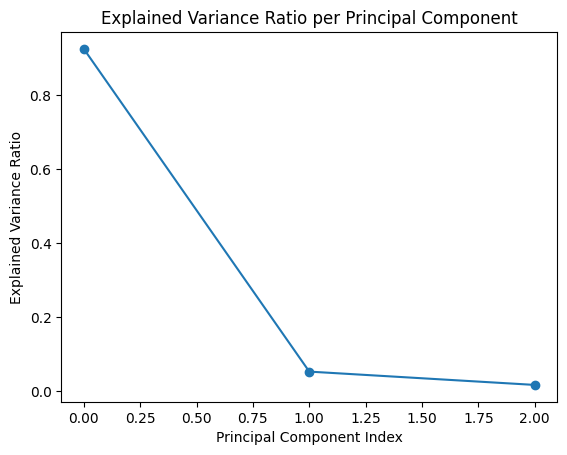

In [7]:
# Initialize PCA model with 3 components
pcaIris = PCA(n_components=3)

# Fit the model on the Iris data (Executes eigendecomposition internally)
pcaIris.fit(data)

# The explained variance ratio represents the percentage of dataset variance captured by each principal component
plt.plot(pcaIris.explained_variance_ratio_, marker='o')
plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.show()


# Projecting the data.

Project the data onto the first two principal components. Since you have class labels you can plot the 2-dimensional representation of the 3 classes in different colours.  The idea is to see how much class separation is obtained by projecting onto the first two principal components.

You should see something like the following - it will not be exactly the same, since the example image was generated on a subset of the data:

(**You need to provide the code in the following code cell**)

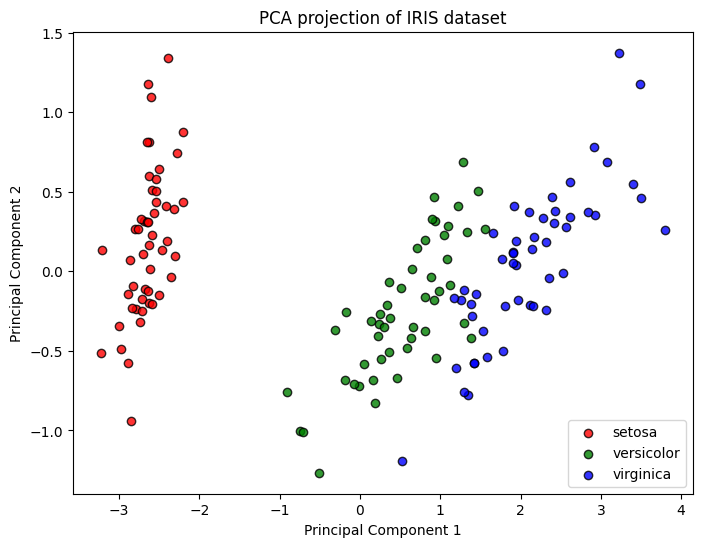

In [8]:
# Project the data onto the first two principal components (Dimensionality Reduction)
pcaIris2D = PCA(n_components=2)
data_2d = pcaIris2D.fit_transform(data)

# Visualize the data projected onto the 2D PCA space
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
for i, target_name in zip([0, 1, 2], iris_data.target_names):
    plt.scatter(data_2d[labels == i, 0], data_2d[labels == i, 1], 
                color=colors[i], label=target_name, alpha=0.8, edgecolor='k')
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA projection of IRIS dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


# LDA Projection
Similarly, project the data using Linear Discriminant Analysis (LDA) to contrast it with PCA. LDA will compute eigenvectors to maximize the margin between classes.

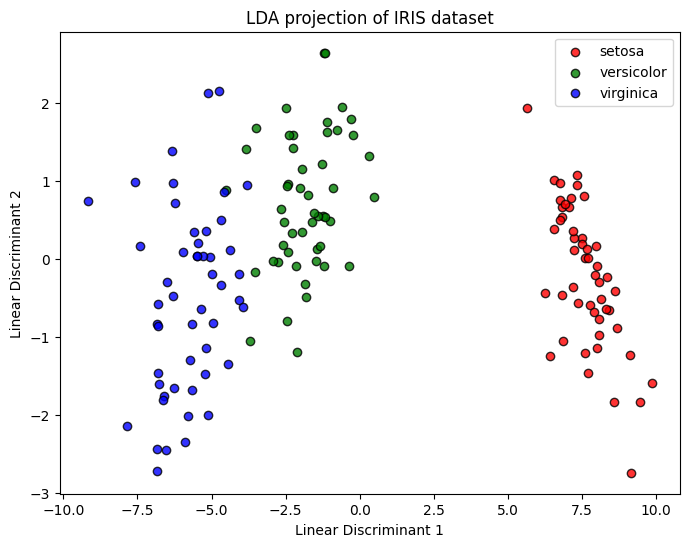

In [9]:
# Apply LDA (Supervised dimensionality reduction)
ldaIris = LDA(n_components=2)
data_lda = ldaIris.fit_transform(data, labels)

# Visualize the data projected onto the 2D LDA space
plt.figure(figsize=(8, 6))
for i, target_name in zip([0, 1, 2], iris_data.target_names):
    plt.scatter(data_lda[labels == i, 0], data_lda[labels == i, 1], 
                color=colors[i], label=target_name, alpha=0.8, edgecolor='k')
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('LDA projection of IRIS dataset')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.show()


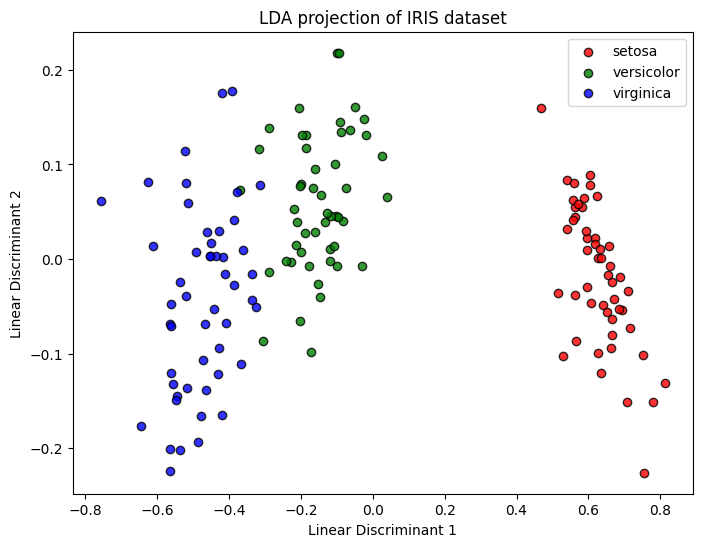

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

def lda_via_svd(X, y, n_components=2):
    """
    Implements LDA using SVD to avoid explicit matrix inversion.
    """
    n_samples, n_features = X.shape
    classes = np.unique(y)
    n_classes = len(classes)
    
    # Compute class priors, class means, and overall mean
    priors = np.array([np.mean(y == c) for c in classes])
    class_means = np.array([np.mean(X[y == c], axis=0) for c in classes])
    overall_mean = np.mean(X, axis=0)
    
    # 1. Within-class scatter whitening (PCA equivalence)
    # Center the data per class
    Xc = np.empty_like(X, dtype=float)
    for i, c in enumerate(classes):
        Xc[y == c] = X[y == c] - class_means[i]
        
    # SVD of centered data (represents within-class scatter)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    
    # Filter zero singular values for numerical stability
    tol = S[0] * 1e-14
    keep = S > tol
    S = S[keep]
    Vt = Vt[keep]
    
    # Whitening matrix: V * S^-1
    scalings = Vt.T @ np.diag(1.0 / S)
    
    # 2. Between-class scatter on whitened means (PCA on centroids)
    # Weight the centered means by sqrt(priors * N)
    M = np.empty((n_classes, scalings.shape[1]))
    for i in range(n_classes):
        M[i, :] = np.sqrt(priors[i] * n_samples) * (class_means[i] - overall_mean) @ scalings
        
    # SVD of between-class scatter
    U_b, S_b, Vt_b = np.linalg.svd(M, full_matrices=False)
    
    # Extract the top components
    rotations = Vt_b.T[:, :n_components]
    
    # 3. Final projection matrix combining whitening and centroid rotations
    coef = scalings @ rotations
    
    # Project the centered data onto the new LDA space
    return (X - overall_mean) @ coef

# --- Execution and Visualization ---
if __name__ == "__main__":
    # Load Iris dataset (strictly for input data generation)
    iris_data = load_iris()
    data = iris_data.data
    labels = iris_data.target
    colors = ['red', 'green', 'blue']
    
    # Apply custom LDA
    data_lda = lda_via_svd(data, labels, n_components=2)
    
    # Visualize the data projected onto the 2D LDA space
    plt.figure(figsize=(8, 6))
    for i, target_name in zip([0, 1, 2], iris_data.target_names):
        plt.scatter(
            data_lda[labels == i, 0], 
            data_lda[labels == i, 1], 
            color=colors[i], 
            label=target_name, 
            alpha=0.8, 
            edgecolor='k'
        )
    plt.legend(loc='best', shadow=False, scatterpoints=1)
    plt.title('LDA projection of IRIS dataset')
    plt.xlabel('Linear Discriminant 1')
    plt.ylabel('Linear Discriminant 2')
    plt.show()